### MNIST 

In [9]:
import numpy as np
from keras.datasets import mnist
%matplotlib inline
from matplotlib import pyplot as plt
from scipy import stats


def load_mnist():
  '''
  Loads, reshapes, and normalizes the data
  '''
  (x_train, y_train), (x_test, y_test) = mnist.load_data() # loads MNIST data
  x_train = x_train[::-1]
  y_train = y_train[::-1]
  x_train = np.reshape(x_train, (len(x_train), 28*28))  # reformat to 784-d vectors
  x_test = np.reshape(x_test, (len(x_test), 28*28))
  maxval = x_train.max()
  x_train = x_train/maxval  # normalize values to range from 0 to 1
  x_test = x_test/maxval
  return (x_train, y_train), (x_test, y_test)


(x_train, y_train), (x_test, y_test) = load_mnist()

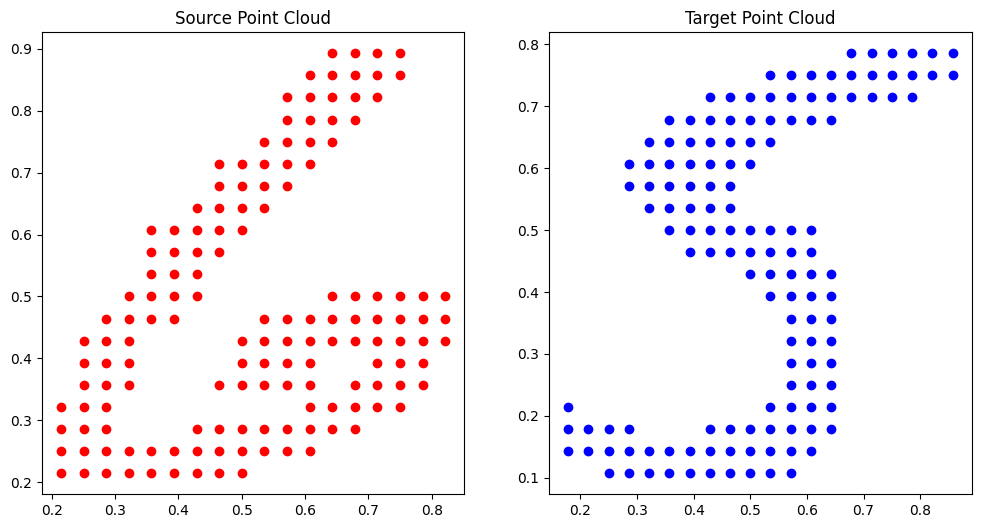

In [10]:

src_pc = np.where(x_train[1] > 0, 1, 0).reshape((28,28)) # 28x28
tgt_pc = np.where(x_train[2] > 0, 1, 0).reshape((28,28)) # 28x28

# convert to 2D point clouds, treating xy coordinates of non-zero pixels as points
src_pc = np.array(np.nonzero(src_pc)).astype(np.float32) # 2xN
tgt_pc = np.array(np.nonzero(tgt_pc)).astype(np.float32)

# post processing points so it looks like mnist image above
# flip y
src_pc[0] = 27 - src_pc[0]
tgt_pc[0] = 27 - tgt_pc[0]
# flip x
src_pc = src_pc[[1,0],:]
tgt_pc = tgt_pc[[1,0],:]

# normalize to 0 1
src_pc = src_pc / 28.0
tgt_pc = tgt_pc / 28.0

# display source and target point clouds
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(121)
ax1.scatter(src_pc[0], src_pc[1], c='r', marker='o')
ax1.set_title('Source Point Cloud')

ax2 = fig.add_subplot(122)
ax2.scatter(tgt_pc[0], tgt_pc[1], c='b', marker='o')
ax2.set_title('Target Point Cloud')

plt.show()


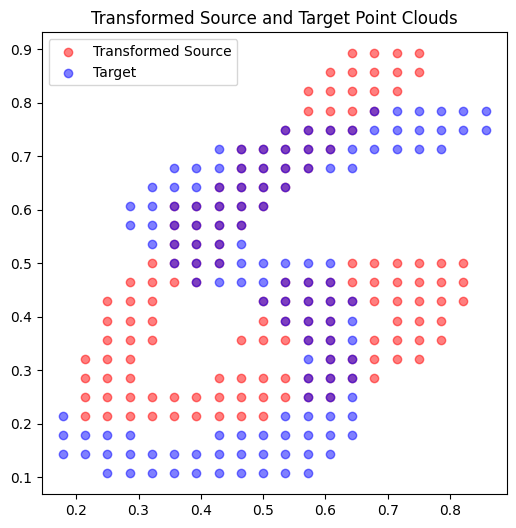

In [11]:
# display transformed source and target point clouds in same plot
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(6, 6))

# transparent set to 0.5
plt.scatter(src_pc[0], src_pc[1], c='r', marker='o', label='Transformed Source', alpha=0.5)
plt.scatter(tgt_pc[0], tgt_pc[1], c='b', marker='o', label='Target', alpha=0.5)
plt.title('Transformed Source and Target Point Clouds')
plt.legend()
plt.show()

[iter 001] rms=5.400445e-02
[iter 002] rms=5.219604e-02
[iter 003] rms=5.072576e-02
[iter 004] rms=4.957295e-02
[iter 005] rms=4.859112e-02
[iter 006] rms=4.779899e-02
[iter 007] rms=4.712524e-02
[iter 008] rms=4.649522e-02
[iter 009] rms=4.592967e-02
[iter 010] rms=4.539803e-02
[iter 011] rms=4.491810e-02
[iter 012] rms=4.444568e-02
[iter 013] rms=4.399501e-02
[iter 014] rms=4.356199e-02
[iter 015] rms=4.316939e-02
[iter 016] rms=4.278001e-02
[iter 017] rms=4.241402e-02
[iter 018] rms=4.205484e-02
[iter 019] rms=4.172567e-02
[iter 020] rms=4.141609e-02
[iter 021] rms=4.113373e-02
[iter 022] rms=4.085453e-02
[iter 023] rms=4.056953e-02
[iter 024] rms=4.030699e-02
[iter 025] rms=4.006122e-02
[iter 026] rms=3.982670e-02
[iter 027] rms=3.961042e-02
[iter 028] rms=3.940345e-02
[iter 029] rms=3.920944e-02
[iter 030] rms=3.902279e-02
[iter 031] rms=3.885293e-02
[iter 032] rms=3.868762e-02
[iter 033] rms=3.850564e-02
[iter 034] rms=3.834051e-02
[iter 035] rms=3.817965e-02
[iter 036] rms=3.802

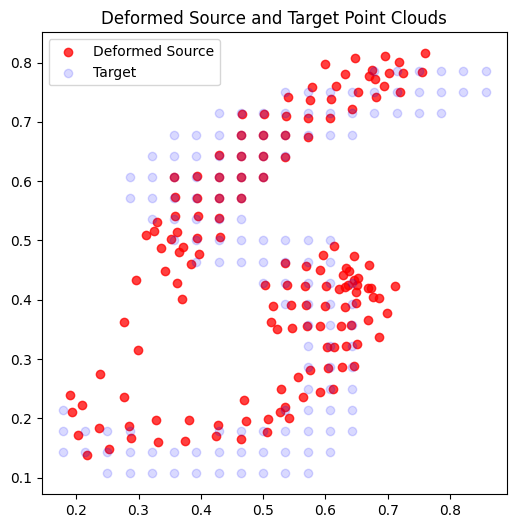

In [12]:
import numpy as np
from scipy.spatial import cKDTree

def nearest_neighbor(src, dst):
    tree = cKDTree(dst)
    dists, idx = tree.query(src)
    return idx, dists

from scipy.spatial.transform import Rotation as R

def deform_step_ctrl(src_curr, tgt, key_idx, radii, alpha=0.5):
    '''deform step using control points'''
    tree = cKDTree(tgt)
    tgt_matches = []
    for idx in key_idx:
        _, j = tree.query(src_curr[idx])
        tgt_matches.append(j)
    tgt_matches = np.array(tgt_matches)

    new_src = np.zeros_like(src_curr)
    for i, p in enumerate(src_curr):
        weighted_sum = np.zeros(2)
        total_w = 0.0
        for k, idx in enumerate(key_idx):
            src_kp = src_curr[idx]
            tgt_kp = tgt[tgt_matches[k]]

            d = np.linalg.norm(p - src_kp)
            if d < radii[k]:
                w = np.exp(-(d**2) / (2 * (radii[k]**2)))  # Gaussian weight
                displacement = tgt_kp - src_kp
                weighted_sum += w * (p + alpha * displacement)
                total_w += w
        if total_w > 0:
            new_src[i] = weighted_sum / total_w
        else:
            new_src[i] = p
    return new_src

def deform_step(src_curr, tgt, key_idx, radii, alpha=0.5):
    '''deform step without control points (1 transformation per point)'''
    tree = cKDTree(tgt)
    new_src = np.zeros_like(src_curr)
    for i, src_pt in enumerate(src_curr):
        _, j = tree.query(src_pt)

        d = np.linalg.norm(tgt[j] - src_pt)
        displacement = tgt[j] - src_pt
        new_src[i] = src_pt + alpha * displacement

    return new_src

def build_knn_graph(points, k=6):
    tree = cKDTree(points)
    dists, idxs = tree.query(points, k=k+1)  # +1 includes self
    neighbors = []
    for i in range(points.shape[0]):
        neigh = idxs[i][1:]  # drop self
        neighbors.append(neigh.tolist())
    return neighbors

def arap_smooth(src_curr, src_orig, neighbors, lam=0.1):
    """
    apply arap smooth by linear interpolate between current position 
    estimated by the icp and local rotational rigidity of the original 
    point cloud
    """
    N = src_curr.shape[0]
    new_pos = src_curr.copy()

    for i in range(N):
        Ni = neighbors[i]
        if len(Ni) == 0:
            continue
        Pi = src_orig[i] - src_orig[Ni]     # original edge vectors
        Qi = src_curr[i] - src_curr[Ni]     # current edge vectors
        M = Qi.T @ Pi
        U, _, Vt = np.linalg.svd(M) # ICP to get rotation
        R = U @ Vt
        new_pos[i] = (1-lam)*src_curr[i] + lam*np.mean(src_curr[Ni] + (R @ Pi.T).T, axis=0)
    return new_pos

def nonrigid_icp_radius_arap(src, tgt, max_iter=50, tol=1e-6,
                             n_ctrl=20, radii=None, alpha=0.5,
                             lam=0.2, k=6, verbose=False, use_ctrl=False):

    src_curr = src.copy().astype(float)
    src_orig = src.copy().astype(float)
    neighbors = build_knn_graph(src_orig, k=k)

    prev_rms = np.inf
    rms_hist = []
    pc_histories = [src_curr.copy()]

    for it in range(max_iter):
        # choose control points (random for now) uniformly from src
        ctrl_idx = np.linspace(0, src_curr.shape[0]-1, n_ctrl).astype(int)
        if radii is None:
            radii_iter = [np.std(src_curr) * 0.5] * n_ctrl
        else:
            radii_iter = radii

        if use_ctrl:
            src_next = deform_step_ctrl(src_curr, tgt, ctrl_idx, radii_iter, alpha)
        else:
            src_next = deform_step(src_curr, tgt, ctrl_idx, radii_iter, alpha)

        src_next = arap_smooth(src_next, src_orig, neighbors, lam=lam)

        idx, d = nearest_neighbor(tgt, src_next)
        rms = np.sqrt(np.mean(d**2))
        rms_hist.append(rms)

        if verbose:
            print(f"[iter {it+1:03d}] rms={rms:.6e}")

        if abs(prev_rms - rms) < tol:
            src_curr = src_next
            break
        prev_rms = rms
        src_curr = src_next
        pc_histories.append(src_curr.copy())

    history = {'rms': rms_hist, 'iters': it+1}
    return src_curr, history, pc_histories, ctrl_idx, radii_iter

# perform registration. change params here
deformed_src_pc2, history2, pc_histories, ctrl_idx, radii_iter = nonrigid_icp_radius_arap(src_pc.T, tgt_pc.T, 
                                                                                          max_iter=100, tol=1e-6, 
                                                                                          n_ctrl=50, alpha=0.25, verbose=True, 
                                                                                          lam=0.03, k=6, use_ctrl=True, radii=[0.01]*50)

# display final plots
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(6, 6))
plt.scatter(deformed_src_pc2[:,0], deformed_src_pc2[:,1], c='r', marker='o', label='Deformed Source', alpha=0.75)
plt.scatter(tgt_pc[0], tgt_pc[1], c='b', marker='o', label='Target', alpha=0.15)
plt.title('Deformed Source and Target Point Clouds')
plt.legend()

# plot history of pc as animation and save video
img_frame = []
for pc in pc_histories:
    fig = plt.figure(figsize=(6, 6))
    plt.scatter(pc[:,0], pc[:,1], c='r', marker='o', label='Deformed Source', alpha=0.75)
    plt.scatter(tgt_pc[0], tgt_pc[1], c='b', marker='o', label='Target', alpha=0.15)
    for i, idx in enumerate(ctrl_idx):
        if i == 0:
            plt.scatter(pc[ctrl_idx, 0], pc[ctrl_idx, 1], c='g', marker='x', label='Control Points', s=100)
        else:
            plt.scatter(pc[ctrl_idx, 0], pc[ctrl_idx, 1], c='g', marker='x', s=100)
        circle = plt.Circle((pc[idx, 0], pc[idx, 1]), radii_iter[i], color='g', fill=False, linestyle='--', alpha=0.5)
        plt.gca().add_artist(circle)
    plt.title('Deformed Source and Target Point Clouds')
    plt.legend()

    # fix size of axes
    plt.xlim(0, 0.9)
    plt.ylim(0, 0.9)

    # save to img_frame
    fig.canvas.draw()
    img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    img = img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
    img_frame.append(img)
    plt.close(fig)

import imageio
imageio.mimsave('deformation_process.gif', img_frame, fps=10, loop=0)

### Pikachu -> Eevee

In [5]:
import cv2
import numpy as np

def extract_boundary(input_path, output_path=None, thickness=1, size=(128, 128)):
    """
    Extracts the boundary of a silhouette and returns a black-and-white image.
    
    Args:
        input_path (str): Path to the silhouette image.
        output_path (str, optional): Path to save the boundary image.
        thickness (int): Thickness of the boundary line.
        size (tuple): Desired resize dimensions (width, height).
        
    Returns:
        boundary_img (numpy.ndarray): Black-and-white boundary image.
    """
    # Load in grayscale
    img = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
    
    # Resize
    img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    
    # Threshold (ensure silhouette is white on black)
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)

    # Find contours
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Create blank black canvas
    boundary_img = np.zeros_like(binary)

    # Draw contours in white
    cv2.drawContours(boundary_img, contours, -1, 255, thickness)

    # Optionally save result
    if output_path:
        cv2.imwrite(output_path, boundary_img)

    return boundary_img


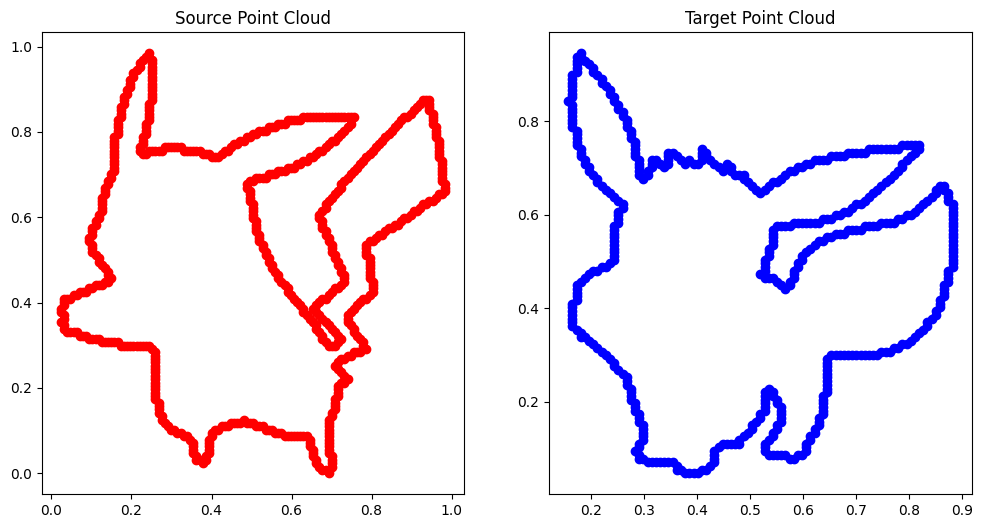

In [6]:
# read the images and resize to 128x128
pikachu_img = extract_boundary('pikachu.jpg', size=(128,128))
eevee_img = extract_boundary('eevee.jpg', size=(128,128))

# convert to 2D point clouds, treating xy coordinates of non-zero pixels as points
src_pc = np.array(np.nonzero(np.array(pikachu_img)>0)).astype(np.float32) # 2xN
tgt_pc = np.array(np.nonzero(np.array(eevee_img)>0)).astype(np.float32) # 2xN

# post processing points so it looks like mnist image above
# flip y
src_pc[0] = 127 - src_pc[0]
tgt_pc[0] = 127 - tgt_pc[0]
# flip x
src_pc = src_pc[[1,0],:]
tgt_pc = tgt_pc[[1,0],:]

# normalize to 0 1
src_pc = src_pc / 127.0
tgt_pc = tgt_pc / 127.0


# display
# display source and target point clouds
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(121)
ax1.scatter(src_pc[0], src_pc[1], c='r', marker='o')
ax1.set_title('Source Point Cloud')

ax2 = fig.add_subplot(122)
ax2.scatter(tgt_pc[0], tgt_pc[1], c='b', marker='o')
ax2.set_title('Target Point Cloud')

plt.show()

[iter 001] rms=4.228876e-02
[iter 002] rms=3.899370e-02
[iter 003] rms=3.668292e-02
[iter 004] rms=3.484363e-02
[iter 005] rms=3.346692e-02
[iter 006] rms=3.236230e-02
[iter 007] rms=3.127885e-02
[iter 008] rms=3.052824e-02
[iter 009] rms=2.988180e-02
[iter 010] rms=2.943562e-02
[iter 011] rms=2.906351e-02
[iter 012] rms=2.872775e-02
[iter 013] rms=2.845264e-02
[iter 014] rms=2.822870e-02
[iter 015] rms=2.806945e-02
[iter 016] rms=2.798693e-02
[iter 017] rms=2.794159e-02
[iter 018] rms=2.793385e-02
[iter 019] rms=2.792403e-02
[iter 020] rms=2.792700e-02
[iter 021] rms=2.793077e-02
[iter 022] rms=2.791390e-02
[iter 023] rms=2.790130e-02
[iter 024] rms=2.788561e-02
[iter 025] rms=2.791785e-02
[iter 026] rms=2.787483e-02
[iter 027] rms=2.785056e-02
[iter 028] rms=2.780777e-02
[iter 029] rms=2.776793e-02
[iter 030] rms=2.772949e-02
[iter 031] rms=2.769578e-02
[iter 032] rms=2.766513e-02
[iter 033] rms=2.763064e-02
[iter 034] rms=2.759713e-02
[iter 035] rms=2.749665e-02
[iter 036] rms=2.738

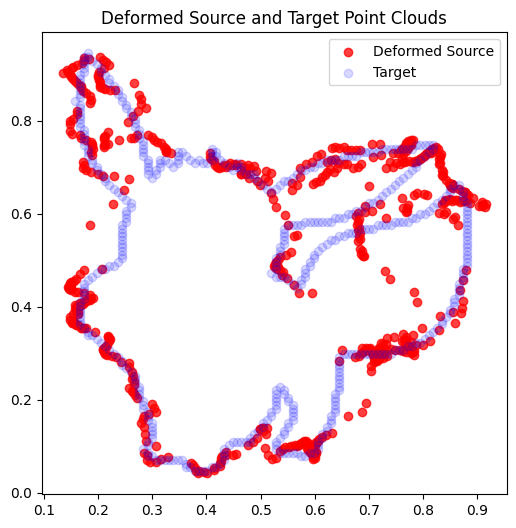

In [7]:
deformed_src_pc2, history2, pc_histories, ctrl_idx, radii_iter = nonrigid_icp_radius_arap(src_pc.T, tgt_pc.T, 
                                                                                          max_iter=100, tol=1e-6, 
                                                                                          n_ctrl=100, alpha=0.25, verbose=True, 
                                                                                          lam=0.01, k=6, use_ctrl=True, radii=[0.07]*100)
# display transformed source and target point clouds in same plot
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(6, 6))
# transparent set to 0.5
plt.scatter(deformed_src_pc2[:,0], deformed_src_pc2[:,1], c='r', marker='o', label='Deformed Source', alpha=0.75)
# plot control pts 
# plt.scatter(src_pc[0,key_indices], src_pc[1,key_indices], c='g', marker='x', label='Control Points', s=100)
plt.scatter(tgt_pc[0], tgt_pc[1], c='b', marker='o', label='Target', alpha=0.15)
# plt.scatter(src_pc[0], src_pc[1], c='g', marker='o', label='Source', alpha=0.15)
plt.title('Deformed Source and Target Point Clouds')
plt.legend()

# plot history of pc as animation and save video
img_frame = []
for pc in pc_histories:
    fig = plt.figure(figsize=(6, 6))
    plt.scatter(pc[:,0], pc[:,1], c='r', marker='o', label='Deformed Source', alpha=0.75)
    plt.scatter(tgt_pc[0], tgt_pc[1], c='b', marker='o', label='Target', alpha=0.15)
    # plot control points
    # plt.scatter(pc[0, ctrl_idx], pc[1, ctrl_idx], c='g', marker='x', label='Control Points', s=100)
    # plot circles for radii
    for i, idx in enumerate(ctrl_idx):
        if i == 0:
            plt.scatter(pc[ctrl_idx, 0], pc[ctrl_idx, 1], c='g', marker='x', label='Control Points', s=100)
        else:
            plt.scatter(pc[ctrl_idx, 0], pc[ctrl_idx, 1], c='g', marker='x', s=100)
        circle = plt.Circle((pc[idx, 0], pc[idx, 1]), radii_iter[i], color='g', fill=False, linestyle='--', alpha=0.5)
        plt.gca().add_artist(circle)
    plt.title('Deformed Source and Target Point Clouds')
    plt.legend()

    # fix size of axes
    plt.xlim(0, 0.9)
    plt.ylim(0, 0.9)

    # save to img_frame
    fig.canvas.draw()
    img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    img = img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
    img_frame.append(img)
    plt.close(fig)

import imageio
imageio.mimsave('deformation_process.gif', img_frame, fps=10, loop=0)